<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [3]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




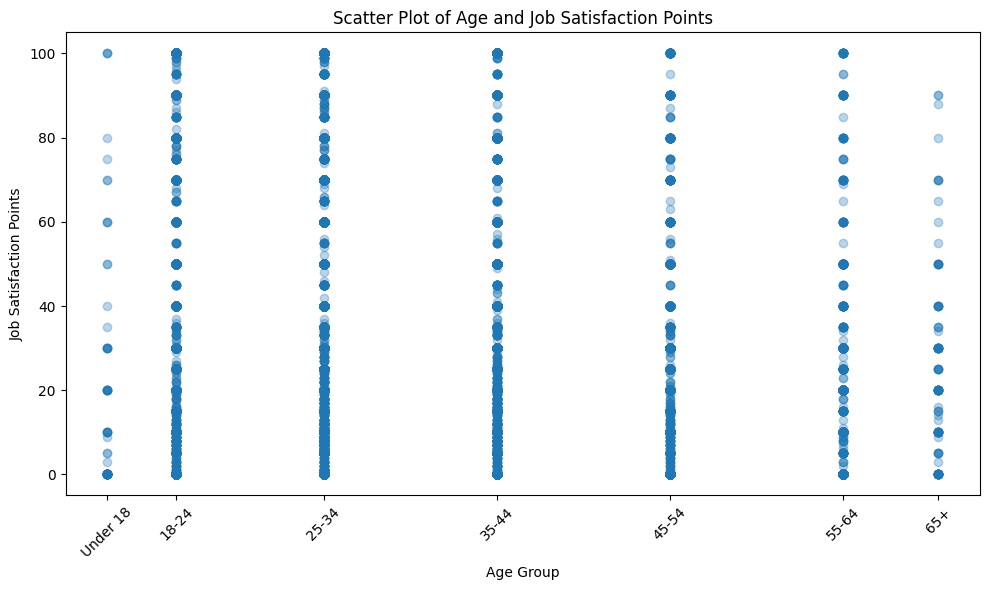

In [4]:
df_scatter = df[["Age", "JobSatPoints_6"]].copy()

# Convert age groups into approximate numeric values
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

df_scatter["AgeNumeric"] = df_scatter["Age"].map(age_map)

# Convert JobSatPoints_6 to numeric
df_scatter["JobSatPoints_6"] = pd.to_numeric(
    df_scatter["JobSatPoints_6"],
    errors="coerce"
)

# Remove missing values
df_scatter = df_scatter.dropna(subset=["AgeNumeric", "JobSatPoints_6"])

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_scatter["AgeNumeric"],
    df_scatter["JobSatPoints_6"],
    alpha=0.3
)

plt.title("Scatter Plot of Age and Job Satisfaction Points")
plt.xlabel("Age Group")
plt.ylabel("Job Satisfaction Points")

plt.xticks(
    [17, 21, 29.5, 39.5, 49.5, 59.5, 65],
    ["Under 18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"],
    rotation=45
)

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


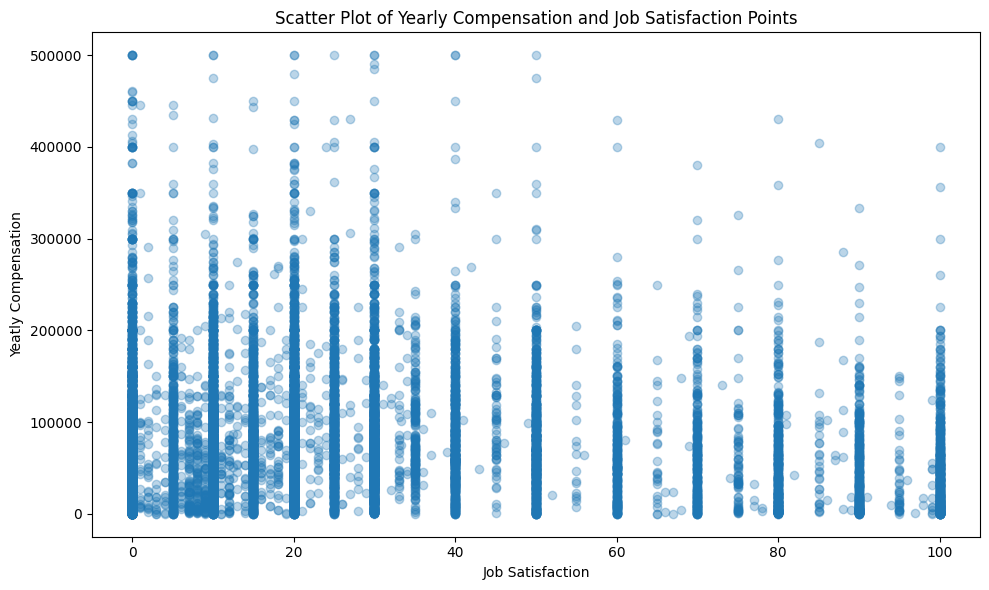

In [13]:
df_scatter = df[["ConvertedCompYearly", "JobSatPoints_6"]].copy()

# Convert JobSatPoints_6 to numeric
df_scatter["JobSatPoints_6"] = pd.to_numeric(
    df_scatter["JobSatPoints_6"],
    errors="coerce"
)

# Remove unrealistic/extreme values
df_scatter = df_scatter[
    (df_scatter["ConvertedCompYearly"] > 0) &
    (df_scatter["ConvertedCompYearly"] <= 500000)
]

# Remove missing values
df_scatter = df_scatter.dropna(subset=["ConvertedCompYearly", "JobSatPoints_6"])

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_scatter["JobSatPoints_6"],
    df_scatter["ConvertedCompYearly"],
    alpha=0.3
)

plt.title("Scatter Plot of Yearly Compensation and Job Satisfaction Points")
plt.xlabel("Job Satisfaction")
plt.ylabel("Yeatly Compensation")



plt.tight_layout()
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


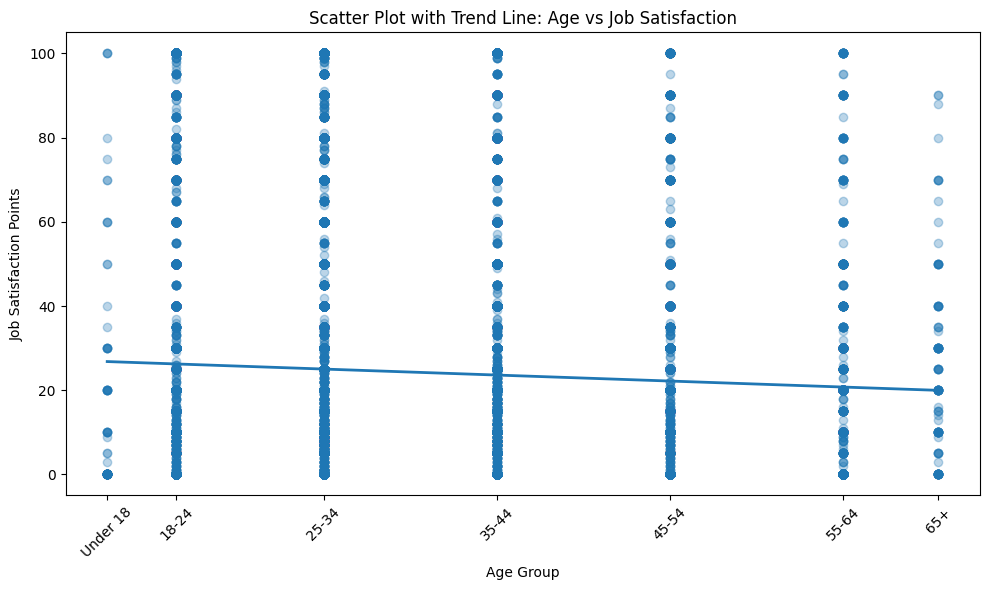

In [14]:
# Keep only the columns needed
df_scatter = df[["Age", "JobSatPoints_6"]].copy()

# Convert Age groups into approximate numeric ages
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

df_scatter["AgeNumeric"] = df_scatter["Age"].map(age_map)

# Convert JobSatPoints_6 to numeric
df_scatter["JobSatPoints_6"] = pd.to_numeric(
    df_scatter["JobSatPoints_6"],
    errors="coerce"
)

# Remove missing values
df_scatter = df_scatter.dropna(subset=["AgeNumeric", "JobSatPoints_6"])

# Calculate regression line manually without numpy
x = df_scatter["AgeNumeric"]
y = df_scatter["JobSatPoints_6"]

slope = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean()) ** 2).sum()
intercept = y.mean() - slope * x.mean()

# Create line values
x_line = [x.min(), x.max()]
y_line = [slope * x_line[0] + intercept, slope * x_line[1] + intercept]

# Plot scatter
plt.figure(figsize=(10, 6))

plt.scatter(
    df_scatter["AgeNumeric"],
    df_scatter["JobSatPoints_6"],
    alpha=0.3
)

# Add trend line
plt.plot(x_line, y_line, linewidth=2)

plt.title("Scatter Plot with Trend Line: Age vs Job Satisfaction")
plt.xlabel("Age Group")
plt.ylabel("Job Satisfaction Points")

plt.xticks(
    [17, 21, 29.5, 39.5, 49.5, 59.5, 65],
    ["Under 18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"],
    rotation=45
)

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


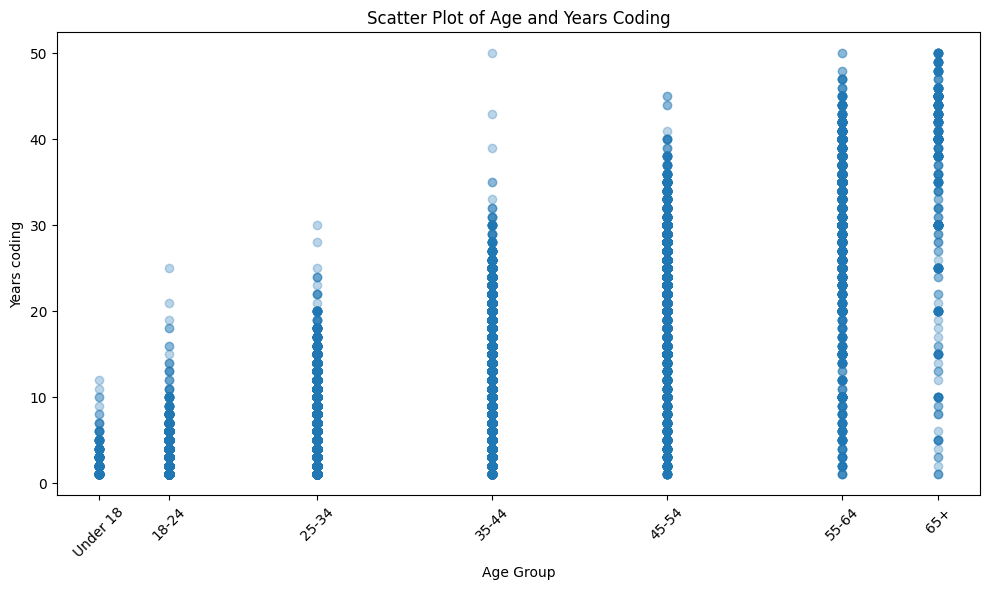

In [16]:
df_scatter = df[["Age", "YearsCodePro"]].copy()

# Convert age groups into approximate numeric values
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

df_scatter["AgeNumeric"] = df_scatter["Age"].map(age_map)

# Convert JobSatPoints_6 to numeric
df_scatter["YearsCodePro"] = pd.to_numeric(
    df_scatter["YearsCodePro"],
    errors="coerce"
)

# Remove missing values
df_scatter = df_scatter.dropna(subset=["AgeNumeric", "YearsCodePro"])

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_scatter["AgeNumeric"],
    df_scatter["YearsCodePro"],
    alpha=0.3
)

plt.title("Scatter Plot of Age and Years Coding")
plt.xlabel("Age Group")
plt.ylabel("Years coding")

plt.xticks(
    [17, 21, 29.5, 39.5, 49.5, 59.5, 65],
    ["Under 18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"],
    rotation=45
)

plt.tight_layout()
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


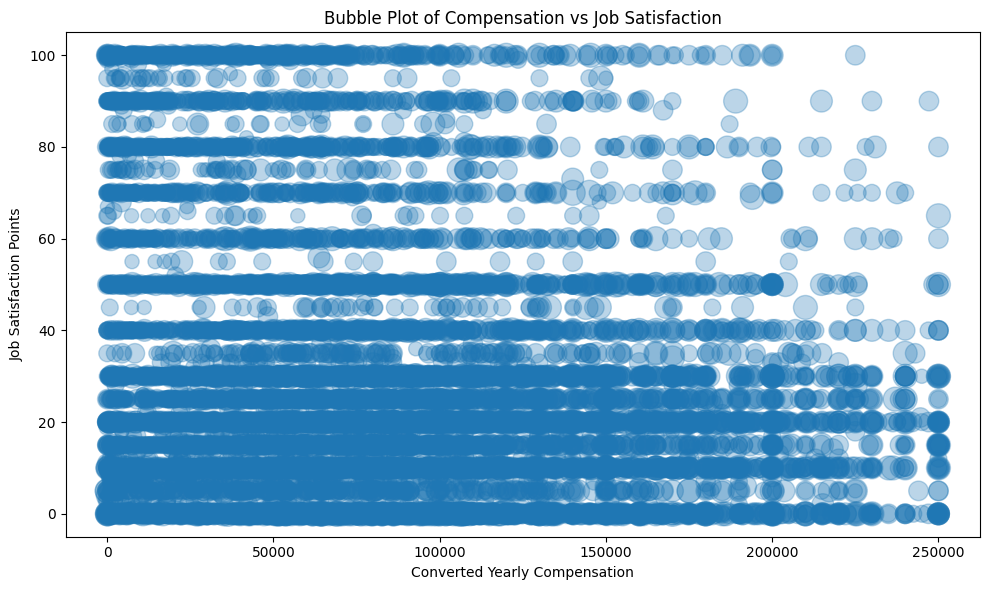

In [17]:
# Keep only the needed columns
df_bubble = df[["ConvertedCompYearly", "JobSatPoints_6", "Age"]].copy()

# Convert compensation and job satisfaction to numeric
df_bubble["ConvertedCompYearly"] = pd.to_numeric(df_bubble["ConvertedCompYearly"], errors="coerce")
df_bubble["JobSatPoints_6"] = pd.to_numeric(df_bubble["JobSatPoints_6"], errors="coerce")

# Convert age groups into approximate numeric ages
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

df_bubble["AgeNumeric"] = df_bubble["Age"].map(age_map)

# Remove missing values
df_bubble = df_bubble.dropna(subset=["ConvertedCompYearly", "JobSatPoints_6", "AgeNumeric"])

# Remove extreme compensation values so the plot is readable
df_bubble = df_bubble[
    (df_bubble["ConvertedCompYearly"] > 0) &
    (df_bubble["ConvertedCompYearly"] <= 250000)
]

# Create bubble sizes
bubble_size = df_bubble["AgeNumeric"] * 5

# Create bubble plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_bubble["ConvertedCompYearly"],
    df_bubble["JobSatPoints_6"],
    s=bubble_size,
    alpha=0.3
)

plt.title("Bubble Plot of Compensation vs Job Satisfaction")
plt.xlabel("Converted Yearly Compensation")
plt.ylabel("Job Satisfaction Points")

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


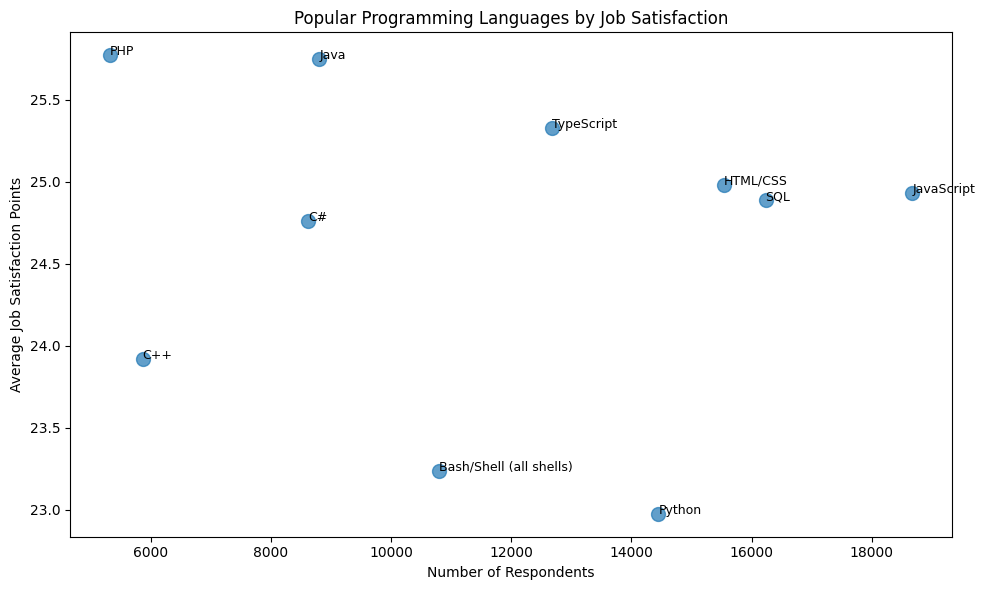

In [18]:
# Keep only the needed columns
df_lang = df[["LanguageHaveWorkedWith", "JobSatPoints_6"]].copy()

# Convert job satisfaction to numeric
df_lang["JobSatPoints_6"] = pd.to_numeric(df_lang["JobSatPoints_6"], errors="coerce")

# Remove missing values
df_lang = df_lang.dropna(subset=["LanguageHaveWorkedWith", "JobSatPoints_6"])

# Split multiple languages into separate rows
df_lang["LanguageHaveWorkedWith"] = df_lang["LanguageHaveWorkedWith"].str.split(";")
df_lang = df_lang.explode("LanguageHaveWorkedWith")

# Clean spaces
df_lang["LanguageHaveWorkedWith"] = df_lang["LanguageHaveWorkedWith"].str.strip()

# Get the top 10 most popular languages
top_languages = df_lang["LanguageHaveWorkedWith"].value_counts().head(10).index

# Keep only top 10 languages
df_top_lang = df_lang[df_lang["LanguageHaveWorkedWith"].isin(top_languages)]

# Calculate average job satisfaction and popularity count for each language
lang_summary = df_top_lang.groupby("LanguageHaveWorkedWith").agg(
    AverageJobSat=("JobSatPoints_6", "mean"),
    Count=("JobSatPoints_6", "count")
).reset_index()

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    lang_summary["Count"],
    lang_summary["AverageJobSat"],
    s=100,
    alpha=0.7
)

# Add language labels to each point
for i in range(len(lang_summary)):
    plt.text(
        lang_summary["Count"].iloc[i],
        lang_summary["AverageJobSat"].iloc[i],
        lang_summary["LanguageHaveWorkedWith"].iloc[i],
        fontsize=9
    )

plt.title("Popular Programming Languages by Job Satisfaction")
plt.xlabel("Number of Respondents")
plt.ylabel("Average Job Satisfaction Points")

plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


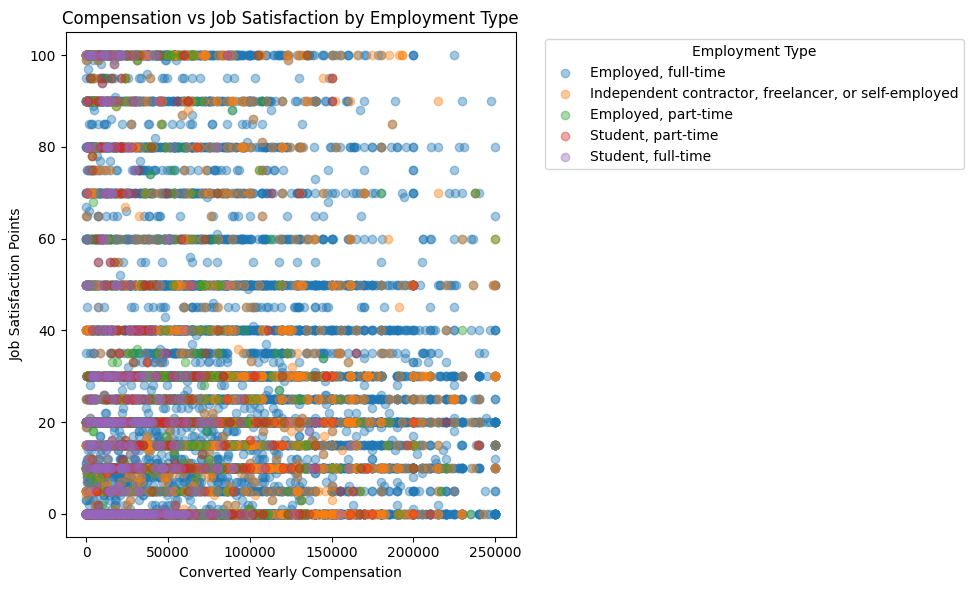

In [19]:
# Keep needed columns
df_emp = df[["ConvertedCompYearly", "JobSatPoints_6", "Employment"]].copy()

# Convert numeric columns
df_emp["ConvertedCompYearly"] = pd.to_numeric(df_emp["ConvertedCompYearly"], errors="coerce")
df_emp["JobSatPoints_6"] = pd.to_numeric(df_emp["JobSatPoints_6"], errors="coerce")

# Remove missing values
df_emp = df_emp.dropna(subset=["ConvertedCompYearly", "JobSatPoints_6", "Employment"])

# Remove extreme compensation values so chart is readable
df_emp = df_emp[
    (df_emp["ConvertedCompYearly"] > 0) &
    (df_emp["ConvertedCompYearly"] <= 250000)
]

# Split multiple employment types into separate rows
df_emp["Employment"] = df_emp["Employment"].str.split(";")
df_emp = df_emp.explode("Employment")
df_emp["Employment"] = df_emp["Employment"].str.strip()

# Keep top 5 employment types
top_employment = df_emp["Employment"].value_counts().head(5).index
df_emp_top = df_emp[df_emp["Employment"].isin(top_employment)]

# Create scatter plot
plt.figure(figsize=(10, 6))

for emp_type in top_employment:
    subset = df_emp_top[df_emp_top["Employment"] == emp_type]
    plt.scatter(
        subset["ConvertedCompYearly"],
        subset["JobSatPoints_6"],
        alpha=0.4,
        label=emp_type
    )

plt.title("Compensation vs Job Satisfaction by Employment Type")
plt.xlabel("Converted Yearly Compensation")
plt.ylabel("Job Satisfaction Points")
plt.legend(title="Employment Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


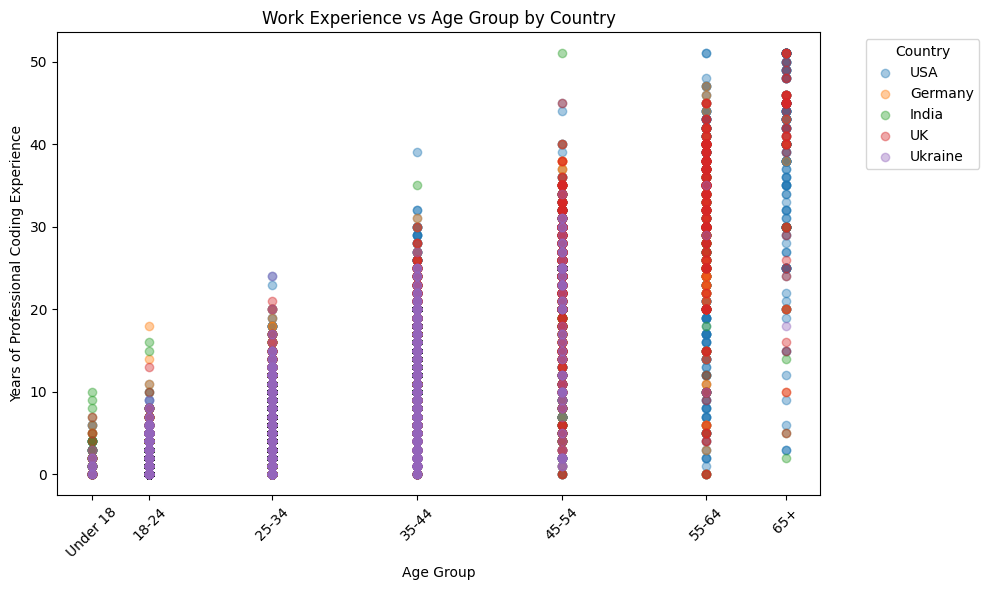

In [26]:
# Keep needed columns
df_exp = df[["YearsCodePro", "Age", "Country"]].copy()

# Convert YearsCodePro text values
df_exp["YearsCodePro"] = df_exp["YearsCodePro"].replace({
    "Less than 1 year": 0,
    "More than 50 years": 51
})

df_exp["YearsCodePro"] = pd.to_numeric(df_exp["YearsCodePro"], errors="coerce")

# Convert Age groups into approximate numeric values
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

df_exp["AgeNumeric"] = df_exp["Age"].map(age_map)

# Remove missing values
df_exp = df_exp.dropna(subset=["YearsCodePro", "AgeNumeric", "Country"])

# Rename to UK and USA
df_exp["Country"] = df_exp["Country"].replace({
    "United States of America": "USA",
    "United Kingdom of Great Britain and Northern Ireland": "UK"
})

# Keep top 5 countries
top_countries = df_exp["Country"].value_counts().head(5).index
df_exp_top = df_exp[df_exp["Country"].isin(top_countries)]

# Create scatter plot
plt.figure(figsize=(10, 6))

for country in top_countries:
    subset = df_exp_top[df_exp_top["Country"] == country]
    plt.scatter(
        subset["AgeNumeric"],
        subset["YearsCodePro"],
        alpha=0.4,
        label=country
    )

plt.title("Work Experience vs Age Group by Country")
plt.xlabel("Age Group")
plt.ylabel("Years of Professional Coding Experience")

plt.xticks(
    [17, 21, 29.5, 39.5, 49.5, 59.5, 65],
    ["Under 18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"],
    rotation=45
)

plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
